In [1]:
import os
import sys
path = os.getcwd()
while True:
    if 'utils.py' in os.listdir(path):
        if path not in sys.path:
            sys.path.append(path)
        break
    new_path = os.path.dirname(path)
    if new_path == path:
        upload_utils = files.upload()
        break
    path = new_path

import utils

/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Llama_3.1_8B_Instruct/Results/checkpoint_scitail_Llama_3.1_8B_Instruct_8bit_zero_shot.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Llama_3.1_8B_Instruct/Results/checkpoint_scitail_Llama_3.1_8B_Instruct_8bit_few_shot_1_examples_entails.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Llama_3.1_8B_Instruct/Results/checkpoint_scitail_Llama_3.1_8B_Instruct_8bit_few_shot_1_examples_neutral.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Llama_3.1_8B_Instruct/Results/checkpoint_scitail_Llama_3.1_8B_Instruct_8bit_few_shot_2_examples.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Llama_3.1_8B_Instruct/Results/checkpoint_scitail_Ll

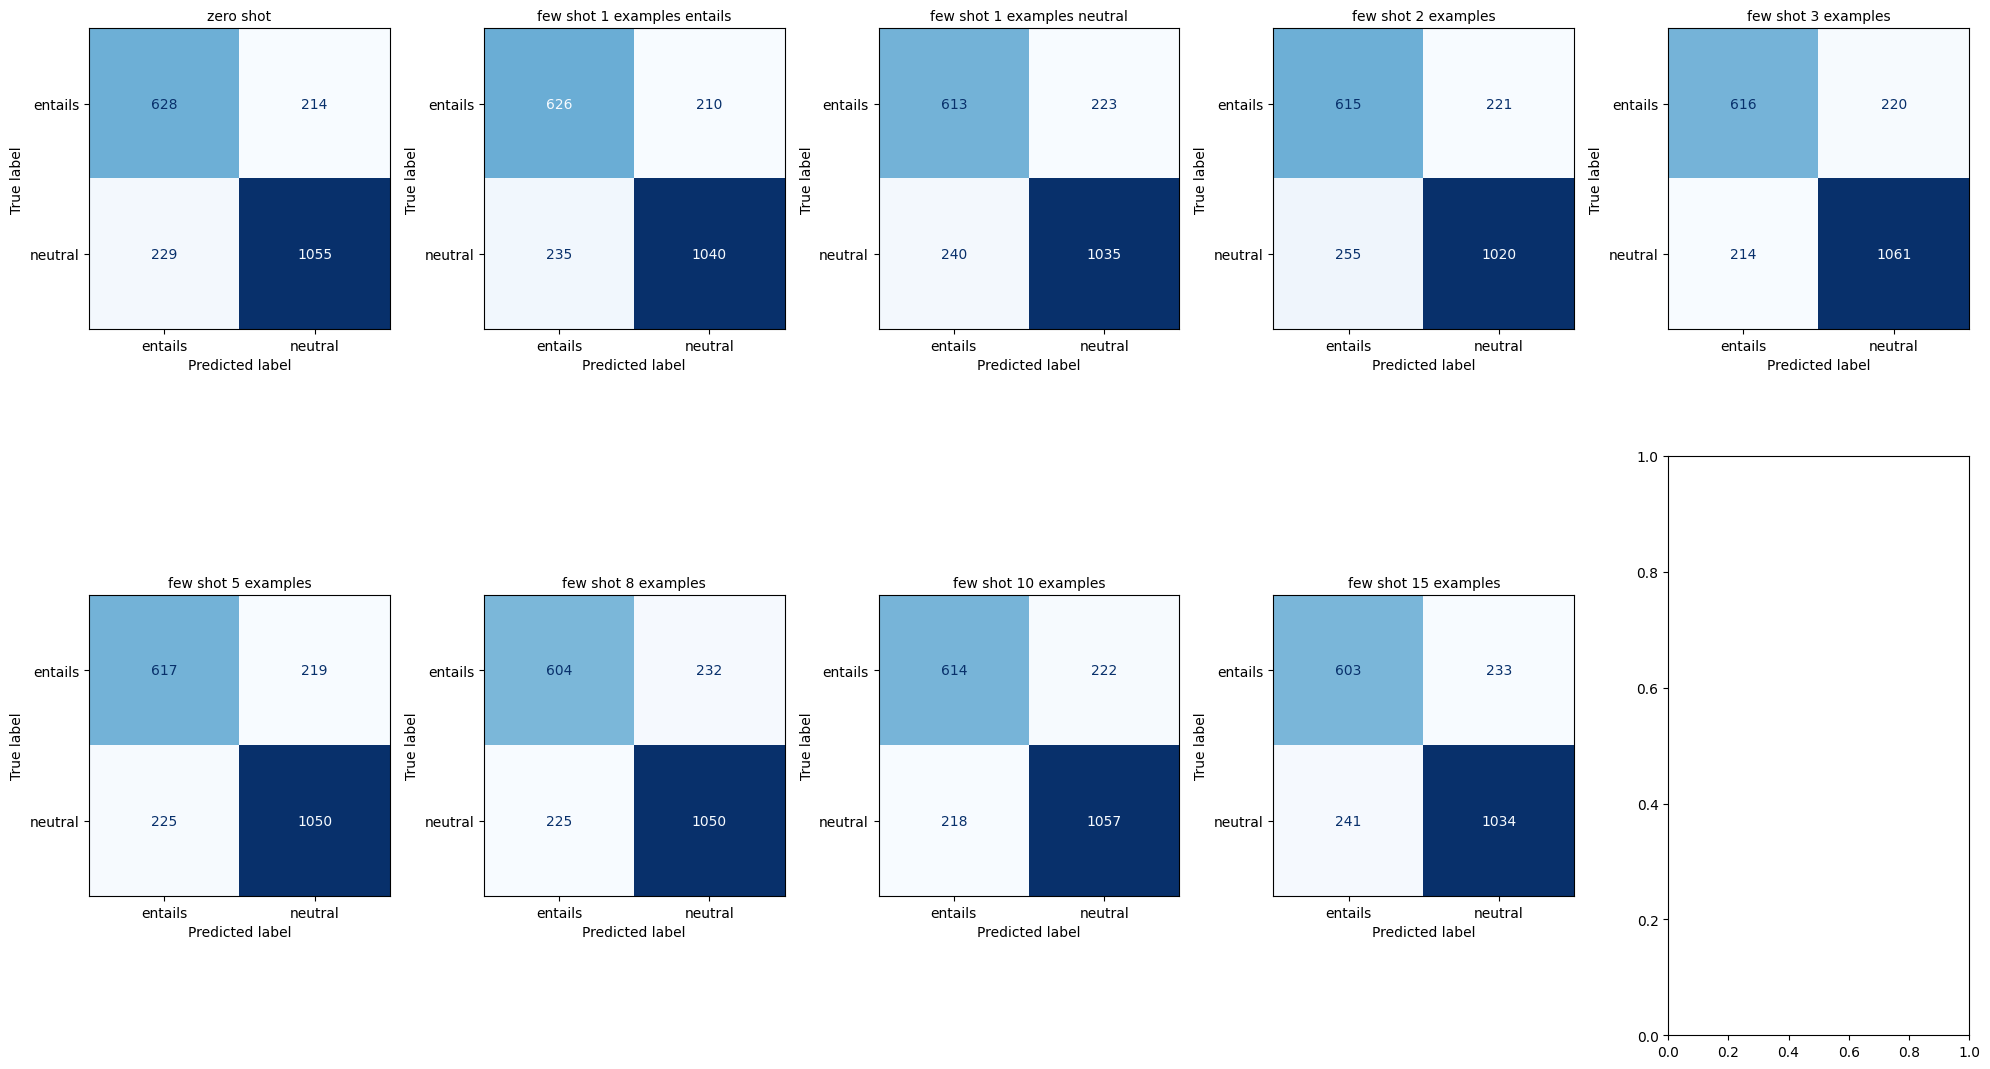

In [23]:
import matplotlib.pyplot as plt

training_modes = [
    'zero shot',
    'few shot 1 examples entails',
    'few shot 1 examples neutral',
    'few shot 2 examples',
    'few shot 3 examples',
    'few shot 5 examples',
    'few shot 8 examples',
    'few shot 10 examples',
    'few shot 15 examples'    
]

fig, axes = plt.subplots(2, 5, figsize=(20,12))
axes = axes.flatten()
accs, precisions, recalls, f1s, mccs, kappas = [], [], [], [], [], []

for idx, mode in enumerate(training_modes):
    global_params = {
            'dataset_type': 'scitail',
            'quantization': '8bit',
            'training_mode': mode,
            'model_id': 'meta-llama/Llama-3.1-8B-Instruct'}
   
    checkpoint_path = utils.create_checkpoint_path(params=global_params)
    predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

    acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                            predicted_labels=predicted_labels,
                                            gold_labels=gold_labels,
                                            params=global_params,
                                            ax=axes[idx]
                                            )   
    accs.append(round(acc, 4))
    precisions.append(round(precision, 4))
    recalls.append(round(recall, 4))
    f1s.append(round(f1, 4))
    mccs.append(round(mcc, 4))
    kappas.append(round(kappa, 4))

plt.tight_layout()
plt.show()

In [24]:
import pandas as pd
labels = [
    "0 examples",
    "1 example (entails)",
    "1 example (neutral)",
    "2 examples",
    "3 examples",
    "5 examples",
    "8 examples",
    "10 examples",
    "15 examples"
]

metrics_df = pd.DataFrame(
    {"Accuracy": accs,
     "Precision": precisions,
     "Recalls": recalls,
     "F1": f1s,
     "MCC": mccs,
     "Kappa": kappas},
     index= labels
)
metrics_df

,Accuracy,Precision,Recalls,F1,MCC,Kappa
0 examples,0.7916,0.7821,0.7837,0.7829,0.5658,0.5658
1 example (entails),0.7892,0.7795,0.7822,0.7808,0.5618,0.5616
1 example (neutral),0.7807,0.7707,0.7725,0.7715,0.5432,0.5431
2 examples,0.7745,0.7644,0.7678,0.7659,0.5322,0.5319
3 examples,0.7944,0.7852,0.7845,0.7848,0.5697,0.5697
5 examples,0.7897,0.7801,0.7808,0.7804,0.5609,0.5609
8 examples,0.7835,0.7738,0.7730,0.7734,0.5468,0.5468
10 examples,0.7916,0.7822,0.7817,0.7820,0.5639,0.5639
15 examples,0.7755,0.7653,0.7661,0.7657,0.5314,0.5314


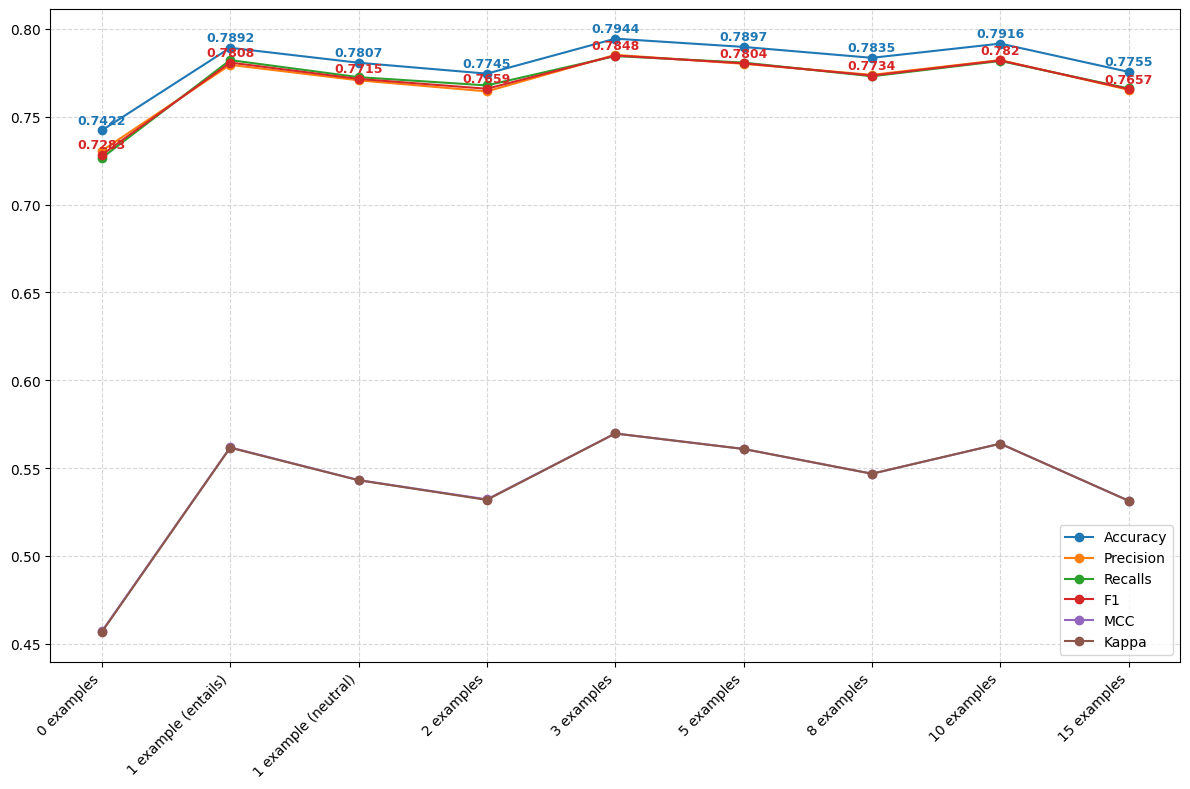

In [21]:
fig, ax = plt.subplots(figsize=(12, 8))

# plot all metrics
metrics_df.plot(kind='line', ax=ax, marker='o')

# set custom x-axis labels
ax.set_xticks(range(len(metrics_df.index)))
ax.set_xticklabels(metrics_df.index, rotation=45, ha='right')

# show grid
ax.grid(True, linestyle='--', alpha=0.5)

# annotate only Accuracy and F1
for metric in ["Accuracy", "F1"]:
    for x, y in enumerate(metrics_df[metric]):
        ax.text(x, y + 0.002, str(y), ha='center', va='bottom', fontsize=9, fontweight='bold', color=ax.get_lines()[list(metrics_df.columns).index(metric)].get_color())

plt.tight_layout()
plt.show()

Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Llama_3.1_8B_Instruct/Results/checkpoint_scitail_Llama_3.1_8B_Instruct_8bit_zero_shot_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Llama_3.1_8B_Instruct/Results/checkpoint_scitail_Llama_3.1_8B_Instruct_8bit_few_shot_1_examples_neutral_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Llama_3.1_8B_Instruct/Results/checkpoint_scitail_Llama_3.1_8B_Instruct_8bit_few_shot_1_examples_entails_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Llama_3.1_8B_Instruct/Results/checkpoint_scitail_Llama_3.1_8B_Instruct_8bit_few_shot_2_examples_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Sci

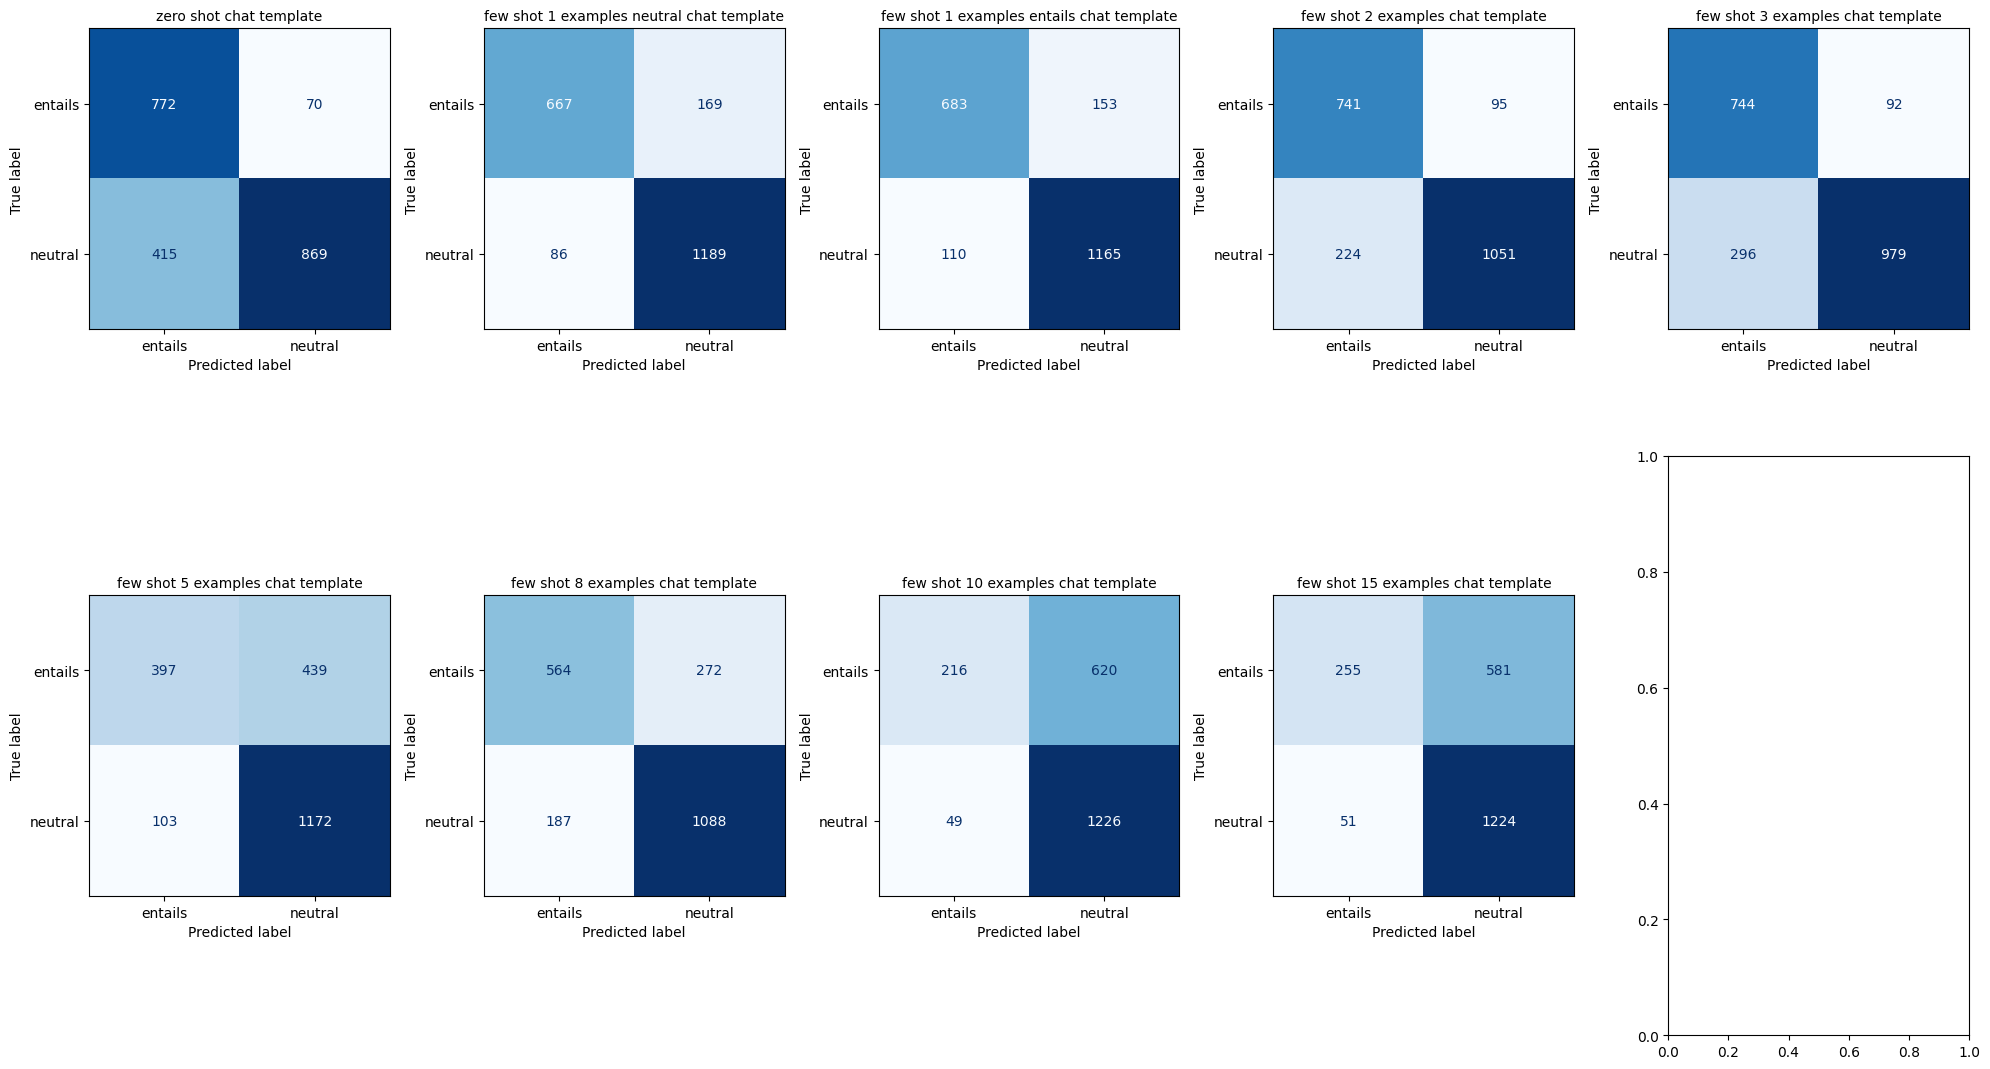

In [3]:
import matplotlib.pyplot as plt

training_modes = [
    'zero shot chat template',
    'few shot 1 examples neutral chat template',
    'few shot 1 examples entails chat template',
    'few shot 2 examples chat template',
    'few shot 3 examples chat template',
    'few shot 5 examples chat template',
    'few shot 8 examples chat template',
    'few shot 10 examples chat template',
    'few shot 15 examples chat template'    
]

fig, axes = plt.subplots(2, 5, figsize=(20,12))
axes = axes.flatten()
accs, precisions, recalls, f1s, mccs, kappas = [], [], [], [], [], []

for idx, mode in enumerate(training_modes):
    global_params = {
            'dataset_type': 'scitail',
            'quantization': '8bit',
            'training_mode': mode,
            'model_id': 'meta-llama/Llama-3.1-8B-Instruct'}
   
    checkpoint_path = utils.create_checkpoint_path(params=global_params)
    predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

    acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                            predicted_labels=predicted_labels,
                                            gold_labels=gold_labels,
                                            params=global_params,
                                            ax=axes[idx]
                                            )   
    accs.append(round(acc, 4))
    precisions.append(round(precision, 4))
    recalls.append(round(recall, 4))
    f1s.append(round(f1, 4))
    mccs.append(round(mcc, 4))
    kappas.append(round(kappa, 4))

plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
labels = [
    "0 examples",
    "1 example (entails)",
    "1 example (neutral)",
    "2 examples",
    "3 examples",
    "5 examples",
    "8 examples",
    "10 examples",
    "15 examples"
]

metrics_df_chat_template = pd.DataFrame(
    {"Accuracy": accs,
     "Precision": precisions,
     "Recalls": recalls,
     "F1": f1s,
     "MCC": mccs,
     "Kappa": kappas},
     index= labels
)
metrics_df_chat_template

,Accuracy,Precision,Recalls,F1,MCC,Kappa
0 examples,0.7719,0.7879,0.7968,0.7714,0.5847,0.5545
1 example (entails),0.8792,0.8807,0.8652,0.8713,0.7457,0.7431
1 example (neutral),0.8754,0.8726,0.8654,0.8686,0.7379,0.7372
2 examples,0.8489,0.8425,0.8553,0.8456,0.6977,0.6923
3 examples,0.8162,0.8147,0.8289,0.8139,0.6435,0.6313
5 examples,0.7432,0.7607,0.6970,0.7033,0.4533,0.4234
8 examples,0.7826,0.7755,0.7640,0.7683,0.5394,0.5374
10 examples,0.6831,0.7396,0.6100,0.5890,0.3247,0.2493
15 examples,0.7006,0.7557,0.6325,0.6207,0.3682,0.2975


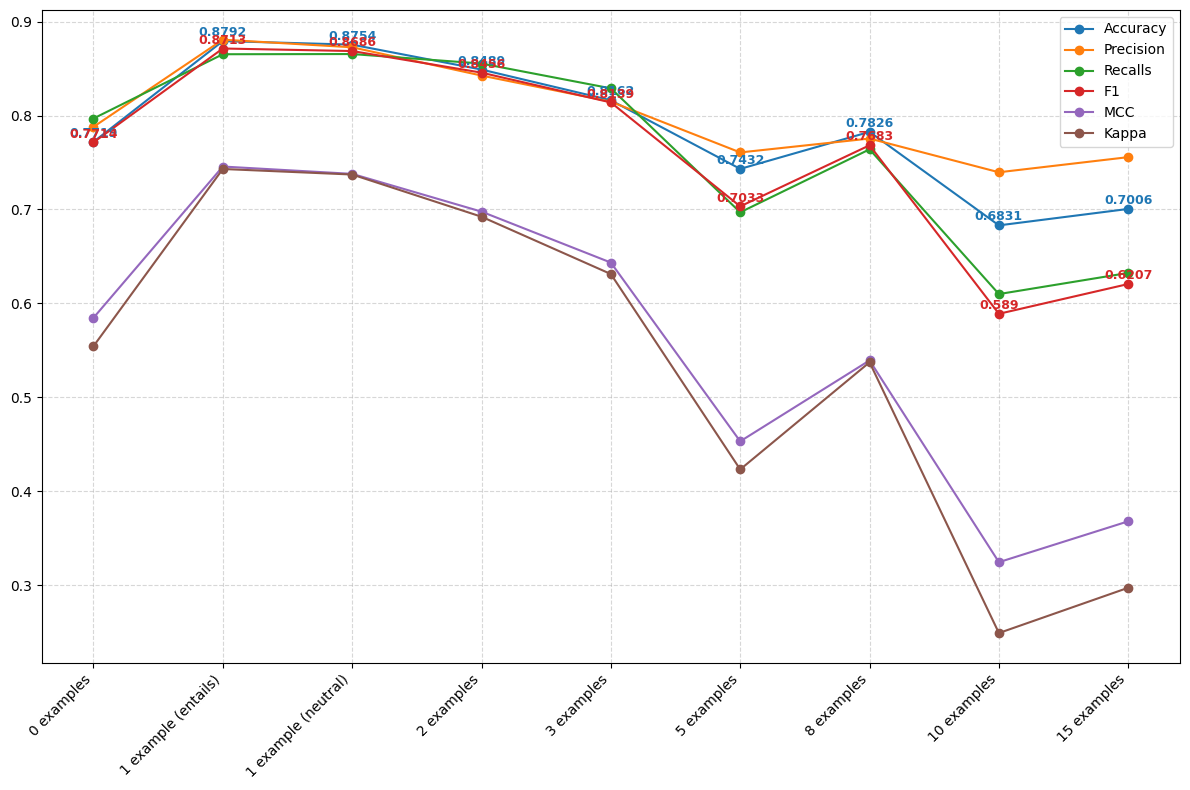

In [5]:
fig, ax = plt.subplots(figsize=(12, 8))

# plot all metrics
metrics_df_chat_template.plot(kind='line', ax=ax, marker='o')

# set custom x-axis labels
ax.set_xticks(range(len(metrics_df_chat_template.index)))
ax.set_xticklabels(metrics_df_chat_template.index, rotation=45, ha='right')

# show grid
ax.grid(True, linestyle='--', alpha=0.5)

# annotate only Accuracy and F1
for metric in ["Accuracy", "F1"]:
    for x, y in enumerate(metrics_df_chat_template[metric]):
        ax.text(x, y + 0.002, str(y), ha='center', va='bottom', fontsize=9, fontweight='bold', color=ax.get_lines()[list(metrics_df_chat_template.columns).index(metric)].get_color())

plt.tight_layout()
plt.show()